In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch as tn
import openmc
from igakit import cad
from igakit import nurbs
from conics import ezellipse
from conics import qtrlobe

from ttnte.xs.benchmarks import kaist
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, eig

tn.set_default_dtype(tn.float64)
tn.set_num_threads(14)

import torch
torch.cuda.empty_cache()

Pi = np.pi
radians = np.radians
degrees = np.degrees

/home/joebogdn/anaconda3/envs/tt_nte/lib/python3.12/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/joebogdn/anaconda3/envs/tt_nte/lib/python3.12/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/joebogdn/anaconda3/envs/tt_nte/lib/python3.12/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [2]:
# Discretization
num_ordinates = 64

# Get XS data
xs_server = kaist()

In [3]:
for mat in xs_server.materials:
    xs_server.scatter_gtg(mat)[1,:,:] = np.zeros((7,7))
    print(xs_server.scatter_gtg(mat).shape)

(2, 7, 7)
(2, 7, 7)
(2, 7, 7)
(2, 7, 7)
(2, 7, 7)
(2, 7, 7)
(2, 7, 7)
(2, 7, 7)
(2, 7, 7)
(2, 7, 7)
(2, 7, 7)


In [4]:
D = 1.26 #fuel width
D2 = D*0.5
X = 1.36 #channel pitch
delta = 0.306 #width of lobes
y2 = delta * 0.5
d = 0.04 #thickness of cladding at valleys
dmax = 0.102 #thickness of cladding at ends of the lobes
R = 0.297 #radius defining outer curve of valleys
a = 0.156 #displacer width


y1 = y2-d #half of width of inner lobe
x1 = (D2 - R - y2 - dmax) #portrusion of innerlobe
x2 = x1 + dmax #portrusion of outer lobe

In [5]:
clad = qtrlobe(outrad = R, portrs= x2, hfwidth = y2, fuelrad=D2)
fuel = qtrlobe(outrad = R+d, portrs= x1, hfwidth = y1, fuelrad=D2-dmax)
origin = cad.line(p0=(0,0),p1=(0,0))
rightedge = cad.line(p1=(X/2,0), p0=(X/2,X/2))
topedge = cad.line(p0=(0,X/2), p1=(X/2,X/2))
po1=(a/(2**0.5),0)
po0=(0,a/(2**0.5))
burn = cad.line(p1=po1,p0=po0)

corner = cad.line(p1=(X/2,X/2), p0=(X/2,X/2))

print(fuel.knots)
print(burn.knots)

(array([0.        , 0.        , 0.        , 0.33333333, 0.33333333,
       0.66666667, 0.66666667, 1.        , 1.        , 1.        ]),)
(array([0., 0., 1., 1.]),)


In [6]:
i=0
m=6
origins = []
absorbs = []
fuels = []
clads = [] 
waters = []

for i in range(0,m):
    origins.append(f"origin{i}")
    absorbs.append(f"absorb{i}")
    fuels.append(f"fuel{i}")
    clads.append(f"clad{i}")
    waters.append(f"water{i}")

    origins[i] = origin.slice(0, i/m, (i+1)/m)
    absorbs[i] = burn.slice(0, i/m, (i+1)/m)
    fuels[i] = fuel.slice(0, i/m, (i+1)/m)
    clads[i] = clad.slice(0, i/m, (i+1)/m)
    i +=1
    
waters[0] = topedge.slice(0, 0, 0.5)
waters[1] = topedge.slice(0, 0.5, 1)
waters[2] = corner.slice(0, 0, 0.5)
waters[3] = corner.slice(0, 0.5, 1)
waters[4] = rightedge.slice(0, 0, 0.5)
waters[5] = rightedge.slice(0, 0.5, 1)



In [ ]:
Absorbs = []
Fuels = []
Clads = [] 
Waters = []


patches = {}

for i in range(0,m):
    print(i)
    Absorbs.append(f"{i}absorb")
    Fuels.append(f"{i}fuel")
    Clads.append(f"{i}clad")
    Waters.append(f"{i}water")

    Absorbs[i] = cad.ruled(origins[i], absorbs[i])
    Fuels[i] = cad.ruled(absorbs[i], fuels[i])
    Clads[i] = cad.ruled(fuels[i], clads[i])
    Waters[i] = cad.ruled(clads[i], waters[i])

    patches[ Absorbs[i] ] = "BA (UO2 FA)"
    patches[ Fuels[i] ] = "UO2 3%"
    patches[ Clads[i] ] = "Guide Tube"
    patches[ Waters[i] ] = "Water"
    i +=1




0
1
2
3
4
5


In [8]:
"""clad1 = clad.slice(0, 0, 1/3)
clad2 = clad.slice(0, 1/3, 2/3)
clad3 = clad.slice(0, 2/3, 1.0)

fuel1 = fuel.slice(0, 0, 1/3)
fuel2 = fuel.slice(0, 1/3, 2/3)
fuel3 = fuel.slice(0, 2/3, 1.0)

burn1 = burn.slice(0, 0,1/3)
burn2 = burn.slice(0, 1/3, 2/3)
burn3 = burn.slice(0, 2/3, 1.0)


origin1 = origin.slice(0,0,1/3)
origin2 = origin.slice(0, 1/3, 2/3)
origin3 = origin.slice(0, 2/3, 1.0)

print(clad1.knots)
print(clad2.knots)
print(burn1.knots)
print(burn2.knots)"""

'clad1 = clad.slice(0, 0, 1/3)\nclad2 = clad.slice(0, 1/3, 2/3)\nclad3 = clad.slice(0, 2/3, 1.0)\n\nfuel1 = fuel.slice(0, 0, 1/3)\nfuel2 = fuel.slice(0, 1/3, 2/3)\nfuel3 = fuel.slice(0, 2/3, 1.0)\n\nburn1 = burn.slice(0, 0,1/3)\nburn2 = burn.slice(0, 1/3, 2/3)\nburn3 = burn.slice(0, 2/3, 1.0)\n\n\norigin1 = origin.slice(0,0,1/3)\norigin2 = origin.slice(0, 1/3, 2/3)\norigin3 = origin.slice(0, 2/3, 1.0)\n\nprint(clad1.knots)\nprint(clad2.knots)\nprint(burn1.knots)\nprint(burn2.knots)'

In [9]:
"""#debugging line

fuela = cad.ruled(origin1, fuel1)
fuelb = cad.ruled(origin2, fuel2)
fuelc = cad.ruled(origin3, fuel3)

watera = cad.ruled(fuel1, topedge)
waterb = cad.ruled(fuel2, corner)
waterc = cad.ruled(fuel3, rightedge)"""

'#debugging line\n\nfuela = cad.ruled(origin1, fuel1)\nfuelb = cad.ruled(origin2, fuel2)\nfuelc = cad.ruled(origin3, fuel3)\n\nwatera = cad.ruled(fuel1, topedge)\nwaterb = cad.ruled(fuel2, corner)\nwaterc = cad.ruled(fuel3, rightedge)'

In [10]:
"""burna = cad.ruled(origin1, burn1)
fuela = cad.ruled(burn1,fuel1)
clada = cad.ruled(fuel1,clad1)
watera = cad.ruled(clad1,topedge)

burnb = cad.ruled(origin2, burn2)
fuelb = cad.ruled(burn2,fuel2)
cladb = cad.ruled(fuel2,clad2)
waterb = cad.ruled(clad2,corner)

burnc = cad.ruled(origin3, burn3)
fuelc = cad.ruled(burn3,fuel3)
cladc = cad.ruled(fuel3,clad3)
waterc = cad.ruled(clad3,rightedge)

print(fuela.knots)
print(fuelb.knots)
print(fuelc.knots)
print(burna.knots)
print(burnb.knots)
print(burnc.knots)
print(clada.knots)
print(cladb.knots)
print(cladc.knots)
print(watera.knots)
print(waterb.knots)
print(waterc.knots)"""

'burna = cad.ruled(origin1, burn1)\nfuela = cad.ruled(burn1,fuel1)\nclada = cad.ruled(fuel1,clad1)\nwatera = cad.ruled(clad1,topedge)\n\nburnb = cad.ruled(origin2, burn2)\nfuelb = cad.ruled(burn2,fuel2)\ncladb = cad.ruled(fuel2,clad2)\nwaterb = cad.ruled(clad2,corner)\n\nburnc = cad.ruled(origin3, burn3)\nfuelc = cad.ruled(burn3,fuel3)\ncladc = cad.ruled(fuel3,clad3)\nwaterc = cad.ruled(clad3,rightedge)\n\nprint(fuela.knots)\nprint(fuelb.knots)\nprint(fuelc.knots)\nprint(burna.knots)\nprint(burnb.knots)\nprint(burnc.knots)\nprint(clada.knots)\nprint(cladb.knots)\nprint(cladc.knots)\nprint(watera.knots)\nprint(waterb.knots)\nprint(waterc.knots)'

In [11]:
"""# NURBS surfaces

patches = {}

#patches[burna] = "BA (UO2 FA)"
patches[fuela] = "UO2 3%"
#patches[clada] = "Guide Tube"
patches[watera] = "Water"

#patches[burnb] = "BA (UO2 FA)"
patches[fuelb] = "UO2 3%"
#patches[cladb] = "Guide Tube"
patches[waterb] = "Water"

#patches[burnc] = "BA (UO2 FA)"
patches[fuelc] = "UO2 3%"
#patches[cladc] = "Guide Tube"
patches[waterc] = "Water"""

'# NURBS surfaces\n\npatches = {}\n\n#patches[burna] = "BA (UO2 FA)"\npatches[fuela] = "UO2 3%"\n#patches[clada] = "Guide Tube"\npatches[watera] = "Water"\n\n#patches[burnb] = "BA (UO2 FA)"\npatches[fuelb] = "UO2 3%"\n#patches[cladb] = "Guide Tube"\npatches[waterb] = "Water"\n\n#patches[burnc] = "BA (UO2 FA)"\npatches[fuelc] = "UO2 3%"\n#patches[cladc] = "Guide Tube"\npatches[waterc] = "Water'

In [12]:
# Create IGA mesh object
mesh = IGAMesh(patches)

# Refine mesh
for p in range(mesh.num_patches):
    mesh.refine(p, 3, 2)
#for p=6 the angular flux error was not decreasing
#stuck at 0.0035
    
# Finalize mesh
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_condition(("left", "bottom", "top", "right"))

# Finalize mesh
mesh.finalize()

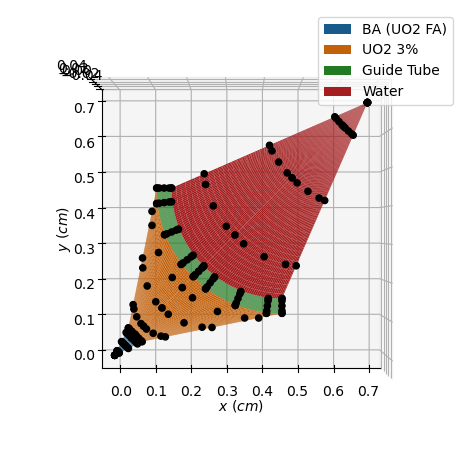

In [13]:
# Plot final mesh
ax = mesh.plot()
ax.view_init(90, -90, 0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("./figs/four_lobeB.png", dpi=300)
plt.show()

In [14]:
print("Assemble system in COOrdinate format")
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
H_m, S_m, F_m, B_in_m, B_out_m = assembler.build()

# Create operators in TT format
print("\nAssemble system in TT format")
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
assembler.interp_jacobian = False
assembler.interp_jacobian_det = False
assembler.interp_boundary_jacobian_det = False
H_tt, S_tt, F_tt, B_in_tt, B_out_tt = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_tt_info("./tt_infoB.csv")

Assemble system in COOrdinate format
Discretization: N = 64, G = 7, P = 8, A = 5, B = 5
Assembling Patch 1
Step            Shape                     Compression  Elapsed Time (s)
H               89600,89600                 16546.63        0.24
S               2,1400,1400                   150.82        0.24
F               1400,1400                      86.18        0.24
B_in            89600,89600                209590.64        0.32
B_out           89600,89600                212976.79        0.38
Assembling Patch 2
Step            Shape                     Compression  Elapsed Time (s)
H               89600,89600                 16546.63        0.61
S               2,1400,1400                   150.82        0.62
F               1400,1400                      86.18        0.62
B_in            89600,89600                205092.99        0.68
B_out           89600,89600                158627.94        0.74
Assembling Patch 3
Step            Shape                     Compression  Elapse

In [15]:
k, psi = eig(
    LHS=LinearOperator([H_tt, B_out_m - B_in_m, -S_tt], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([F_tt], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
    linear_solver_opts={
        "max_iterations": 200,
        "threshold": 1e-10,
        "resets": 20,
    },
)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy().reshape(
    (xs_server.num_groups, mesh.num_patches, -1)
)

Starting power iteration
-- (0): k = 1.07636472, Angular Flux L2-Error = 1.18521967, Elapsed Time = 24.024
-- (1): k = 1.07761681, Angular Flux L2-Error = 0.03721936, Elapsed Time = 47.923
-- (2): k = 1.07776789, Angular Flux L2-Error = 0.01466009, Elapsed Time = 71.86
-- (3): k = 1.07770495, Angular Flux L2-Error = 0.0128109, Elapsed Time = 95.967
-- (4): k = 1.07767027, Angular Flux L2-Error = 0.00602435, Elapsed Time = 121.052
-- (5): k = 1.07766917, Angular Flux L2-Error = 0.00099379, Elapsed Time = 145.188
-- (6): k = 1.07766915, Angular Flux L2-Error = 3.25e-06, Elapsed Time = 169.153
-- (7): k = 1.07766915, Angular Flux L2-Error = 3.2e-07, Elapsed Time = 193.376
-- (8): k = 1.07766915, Angular Flux L2-Error = 3e-08, Elapsed Time = 218.437
-- (9): k = 1.07766915, Angular Flux L2-Error = 0.0, Elapsed Time = 242.396
-- Converged: k = 1.07766915, Elapsed Time = 242.396


In [16]:
# Get OpenMC solution
import numpy as np
k_mc = [0.83940, 0.00005]
phi_mc = np.load("./lightbridge_openmc_absorber/data/mesh_flux.npy")

# Ensure OpenMC solution is normalized
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

# Calculate eigenvalue error
print("keff error: {} +/- {} pcm".format((k - k_mc[0]) * 1e5, k_mc[1]))

keff error: 23826.915254711355 +/- 5e-05 pcm


In [17]:
# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Plot
    fig = mesh.plot(backend="plotly")
    fig.update_layout(scene={"zaxis_title": f"Scalar Flux (g = {g + 1})"})
    fig.write_html(f"./figs/phi_{g + 1}B.html")
    del fig